In [24]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
import warnings 

warnings.filterwarnings('ignore')

In [25]:

df = pd.read_csv('study_hours_scores.csv')
print(df)

    Hours_Studied  Exam_Score
0            4.37       44.14
1            9.56       94.07
2            7.59       76.34
3            6.39       53.94
4            2.40       22.94
..            ...         ...
95           5.44       50.36
96           5.70       56.66
97           4.85       50.18
98           1.23       13.67
99           1.97       23.85

[100 rows x 2 columns]


In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Hours_Studied  100 non-null    float64
 1   Exam_Score     100 non-null    float64
dtypes: float64(2)
memory usage: 1.7 KB


In [27]:
df.describe()

,Hours_Studied,Exam_Score
count,100.000000,100.000000
mean,5.232100,52.311100
std,2.677397,26.477629
min,1.050000,9.470000
25%,2.735000,29.730000
50%,5.175000,49.990000
75%,7.575000,76.092500
max,9.880000,102.730000


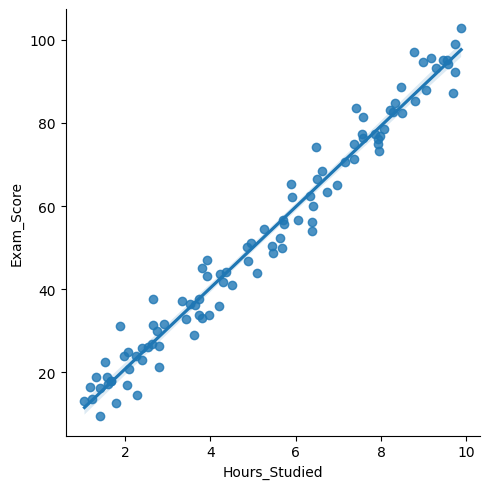

In [28]:
sns.lmplot(x='Hours_Studied',y='Exam_Score',data=df)

In [29]:
x=df[['Hours_Studied']]
y=df[['Exam_Score']]
x

,Hours_Studied
0,4.37
1,9.56
2,7.59
3,6.39
4,2.40
...,...
95,5.44
96,5.70
97,4.85
98,1.23


In [30]:
y

,Exam_Score
0,44.14
1,94.07
2,76.34
3,53.94
4,22.94
...,...
95,50.36
96,56.66
97,50.18
98,13.67


<Axes: >

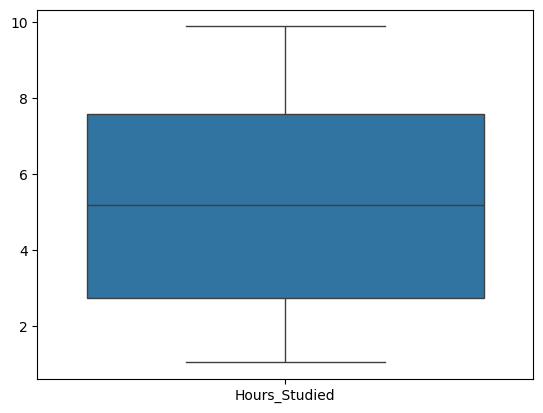

In [31]:
sns.boxplot(x)

In [32]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=.2,random_state=45)
x_train.head()

,Hours_Studied
45,6.96
9,7.37
20,6.51
18,4.89
73,8.34


In [33]:
y_train.head()

,Exam_Score
45,65.08
9,71.22
20,66.55
18,46.91
73,84.88


In [34]:
x_test.head()

,Hours_Studied
0,4.37
1,9.56
62,8.46
76,7.94
37,1.88


In [35]:
y_test.head()

,Exam_Score
0,44.14
1,94.07
62,88.65
76,76.01
37,31.11


In [36]:
from sklearn.linear_model import LinearRegression
lr=LinearRegression()
lr.fit(x_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [37]:
ypred=lr.predict(x_test)
ypred

array([[43.74235018],
       [94.47085077],
       [83.71914544],
       [78.6365211 ],
       [19.40439903],
       [20.28408401],
       [42.37395132],
       [71.0125846 ],
       [75.21552395],
       [38.17101196],
       [45.01300626],
       [28.39673439],
       [97.59861959],
       [94.27536521],
       [79.0274922 ],
       [24.48702336],
       [77.75683612],
       [87.04239981],
       [12.6601475 ],
       [72.96744011]])

In [38]:
result=pd.DataFrame(columns=['Actual','Predicted'])
result['Actual']=y_test
result['Predicted']=ypred
result.reset_index()
result

,Actual,Predicted
0,44.14,43.742350
1,94.07,94.470851
62,88.65,83.719145
76,76.01,78.636521
37,31.11,19.404399
99,23.85,20.284084
78,43.73,42.373951
38,70.62,71.012585
2,76.34,75.215524
84,33.12,38.171012


In [39]:
from sklearn.metrics import r2_score
r2_score(y_test,ypred)

0.9813430263077072